# Phase 0 — Exploring real AIS data

Objective (see [domain/08-phases.md](../domain/08-phases.md#phase-0--setup-and-data-validation)):
confirm that real AIS data from the Danish Maritime Authority supports the model in
[domain/04-data-model.md](../domain/04-data-model.md) *before* writing the pipeline.

Port chosen for the minimal cut ([domain/07-scope-cutlines.md](../domain/07-scope-cutlines.md)): **Aarhus**.

Source: `http://aisdata.ais.dk` — daily files `aisdk-YYYY-MM-DD.zip`, published since 2024.
The most recent file available at the time of this exploration is `2025-02-26`.

## 1. Download (idempotent)

In [1]:
import urllib.request
import zipfile
from pathlib import Path

import pandas as pd

DATE = "2025-02-26"
RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)
ZIP_PATH = RAW_DIR / f"aisdk-{DATE}.zip"
CSV_NAME = f"aisdk-{DATE}.csv"
SOURCE_URL = f"http://aisdata.ais.dk.s3.eu-central-1.amazonaws.com/{DATE[:4]}/aisdk-{DATE}.zip"

if not ZIP_PATH.exists():
    print(f"Downloading {SOURCE_URL} ...")
    urllib.request.urlretrieve(SOURCE_URL, ZIP_PATH)
else:
    print(f"{ZIP_PATH} already exists ({ZIP_PATH.stat().st_size / 1e6:.0f} MB) — skipping download.")

../data/raw/aisdk-2025-02-26.zip already exists (590 MB) — skipping download.


## 2. Real CSV schema

The compressed file is ~590MB; the uncompressed CSV is ~3.1GB (AIS coverage of all of
Denmark in one day). We don't extract it whole to disk: we stream-read it directly from the
zip, in chunks, filtering by the port's bounding box as we go.

In [2]:
with zipfile.ZipFile(ZIP_PATH) as zf:
    with zf.open(CSV_NAME) as f:
        header_df = pd.read_csv(f, nrows=5)

# the source CSV has the first header as "# Timestamp" (comment mark + name)
header_df = header_df.rename(columns={"# Timestamp": "Timestamp"})
header_df

,Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,26/02/2025 00:00:00,Class A,232008874,55.710755,4.727047,Restricted maneuverability,NaN,9.3,140.3,140.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,26/02/2025 00:00:00,Base Station,2190064,56.716553,11.519025,Unknown value,NaN,NaN,NaN,NaN,...,NaN,GPS,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,26/02/2025 00:00:00,Class A,219000873,56.990905,10.304557,Under way using engine,NaN,0.0,41.4,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,26/02/2025 00:00:00,Base Station,2194006,55.538870,5.033200,Unknown value,NaN,NaN,NaN,NaN,...,NaN,Surveyed,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,26/02/2025 00:00:00,Class A,219006113,57.321248,11.126987,Engaged in fishing,0.0,0.0,177.2,158.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


In [3]:
list(header_df.columns)

['Timestamp',
 'Type of mobile',
 'MMSI',
 'Latitude',
 'Longitude',
 'Navigational status',
 'ROT',
 'SOG',
 'COG',
 'Heading',
 'IMO',
 'Callsign',
 'Name',
 'Ship type',
 'Cargo type',
 'Width',
 'Length',
 'Type of position fixing device',
 'Draught',
 'Destination',
 'ETA',
 'Data source type',
 'A',
 'B',
 'C',
 'D']

## 3. Filter to Aarhus's bounding box

Bounding box deliberately wide: it covers the port, the access channel, and the outer
anchorage (where vessels wait their turn) — if we make it too tight, we lose exactly the
waiting events the congestion metric relies on ([domain/04-data-model.md](../domain/04-data-model.md)).

In [4]:
LAT_MIN, LAT_MAX = 56.05, 56.25
LON_MIN, LON_MAX = 10.05, 10.40

CHUNKSIZE = 500_000
matched_chunks = []
rows_scanned = 0

with zipfile.ZipFile(ZIP_PATH) as zf:
    with zf.open(CSV_NAME) as f:
        for chunk in pd.read_csv(f, chunksize=CHUNKSIZE, low_memory=False):
            chunk = chunk.rename(columns={"# Timestamp": "Timestamp"})
            rows_scanned += len(chunk)
            mask = (
                chunk["Latitude"].between(LAT_MIN, LAT_MAX)
                & chunk["Longitude"].between(LON_MIN, LON_MAX)
            )
            hit = chunk[mask]
            if len(hit):
                matched_chunks.append(hit)

aarhus_df = pd.concat(matched_chunks, ignore_index=True)
print(f"Rows scanned (all of Denmark):     {rows_scanned:,}")
print(f"Rows in Aarhus's bounding box:      {len(aarhus_df):,}")
print(f"% of national traffic that is Aarhus: {len(aarhus_df) / rows_scanned:.2%}")

Rows scanned (all of Denmark):     17,350,107
Rows in Aarhus's bounding box:      123,220
% of national traffic that is Aarhus: 0.71%


## 4. Static field coverage

This is what decides whether `vessel_history` ([domain/05-agent-tools-eval.md](../domain/05-agent-tools-eval.md))
will be able to show a vessel name, or whether we need to fall back on MMSI as the primary
identifier and treat the name as optional throughout the chain.

In [5]:
n = len(aarhus_df)

def pct_known(series, unknown_values=("Unknown", "Undefined")):
    known = series.notna() & ~series.isin(unknown_values) & (series.astype(str).str.strip() != "")
    return known.sum() / n

coverage = {
    "Name": pct_known(aarhus_df["Name"]),
    "IMO": pct_known(aarhus_df["IMO"]),
    "Callsign": pct_known(aarhus_df["Callsign"]),
    "Ship type": pct_known(aarhus_df["Ship type"]),
    "Destination": pct_known(aarhus_df["Destination"]),
}
pd.Series(coverage, name="% rows with a known value").map(lambda x: f"{x:.1%}")

Name           97.7%
IMO            69.8%
Callsign       94.1%
Ship type      99.6%
Destination    76.4%
Name: % rows with a known value, dtype: str

In [6]:
aarhus_df["Type of mobile"].value_counts(normalize=True).map(lambda x: f"{x:.1%}")

Type of mobile
Class A    94.1%
Class B     5.9%
Name: proportion, dtype: str

## 5. Coverage per vessel, not per row

A vessel that transmits its static message (type 5) once a day already has a name/IMO that can
be joined to *all* of its position rows via MMSI in the silver layer. The metric that matters
for the pipeline isn't "% of rows with a name" but "% of vessels (unique MMSI) for which at
least one row has a known name".

In [7]:
class_a = aarhus_df[aarhus_df["Type of mobile"] == "Class A"]
vessels_total = class_a["MMSI"].nunique()

has_name = class_a.groupby("MMSI")["Name"].apply(
    lambda s: pct_known(s) > 0
)
vessels_with_name = has_name.sum()

print(f"Unique vessels (Class A) in Aarhus:          {vessels_total}")
print(f"With a known name in at least 1 message:      {vessels_with_name} ({vessels_with_name / vessels_total:.1%})")

Unique vessels (Class A) in Aarhus:          21
With a known name in at least 1 message:      20 (95.2%)


## 6. Position frequency (is it enough for geofencing?)

To reliably detect arrival/departure, we need the interval between consecutive position
messages from the same vessel to be small compared to the duration of a port-entry maneuver
(minutes, not hours).

In [8]:
pos = class_a.copy()
pos["Timestamp"] = pd.to_datetime(pos["Timestamp"], format="%d/%m/%Y %H:%M:%S")
pos = pos.sort_values(["MMSI", "Timestamp"])
pos["gap_seconds"] = pos.groupby("MMSI")["Timestamp"].diff().dt.total_seconds()

pos["gap_seconds"].describe(percentiles=[0.5, 0.9, 0.99])

count    115949.000000
mean         13.273362
std         143.321025
min           0.000000
50%           2.000000
90%          20.000000
99%         180.000000
max       27241.000000
Name: gap_seconds, dtype: float64

## 7. Visualization: does the bounding box make sense?

Scatter of positions to visually confirm the box covers the port and access channel without
cutting off relevant areas, and isn't so wide that it mixes in passing traffic unrelated to
the port.

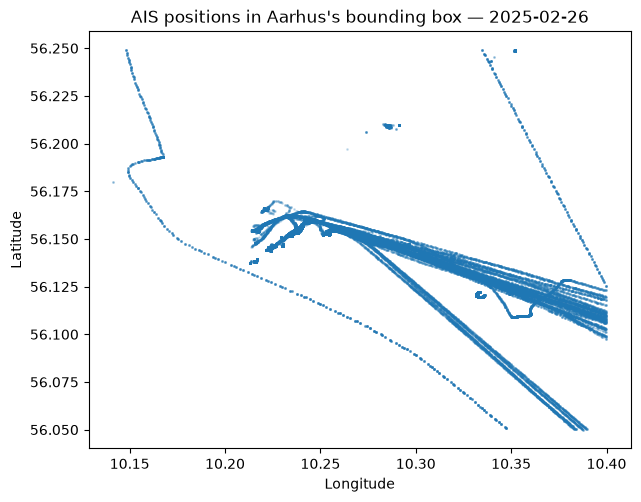

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(aarhus_df["Longitude"], aarhus_df["Latitude"], s=1, alpha=0.2)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"AIS positions in Aarhus's bounding box — {DATE}")
ax.set_aspect("equal")
plt.show()

## 8. Save the filtered subset

This parquet is the input for Phase 1 ([domain/08-phases.md](../domain/08-phases.md#phase-1--data-pipeline-bronze--silver--gold)) —
it avoids having to re-scan the 3.1GB national file every time the bronze pipeline runs.

In [10]:
INTERIM_DIR = Path("../data/interim")
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
out_path = INTERIM_DIR / f"aarhus-{DATE}.parquet"
aarhus_df.to_parquet(out_path, index=False)
print(f"Saved: {out_path} ({out_path.stat().st_size / 1e6:.1f} MB, {len(aarhus_df):,} rows)")

Saved: ../data/interim/aarhus-2025-02-26.parquet (2.5 MB, 123,220 rows)


## Conclusions (with real data from 2025-02-26)

**Phase 0 gate: passes, with two nuances to resolve in Phase 1.**

- **Static field coverage — sufficient.** `Name` 97.7% of rows, `Ship type` 99.6%,
  `Callsign` 94.1%. At the vessel level (not row level), 20 of 21 Class A vessels (95.2%) have a
  known name in at least one message — `vessel_history`
  ([domain/05-agent-tools-eval.md](../domain/05-agent-tools-eval.md)) can show a name in
  almost every case, with MMSI as a fallback for the rest. `IMO` covers only 69.8% (expected:
  not every Class A vessel is SOLAS-class) — treat it as optional, never as a PK.

- **Position frequency — more than enough, but dedup is needed.** The median gap
  between consecutive messages from the same MMSI is **2 seconds**, well below what's needed
  for geofencing port maneuvers. Such a small gap suggests redundant messages
  received by multiple base stations — confirms that the dedup step in
  bronze→silver ([04-data-model.md](../domain/04-data-model.md)) isn't optional, it's necessary
  to avoid inflating enter/exit event counts.

- **A finding that changes the plan: low volume.** Only **21 unique Class A vessels** entered the
  bounding box in the entire day (123,220 rows, 0.71% of national traffic). That's low to sustain
  a "7-day congestion" series with interesting statistical variation. Two paths for
  Phase 1, to decide with more days of data:
  1. Widen the bounding box to capture more approach/outer-anchorage traffic (not just
     the inner harbor), or
  2. Accept Aarhus's real volume and adjust the "congestion" metric to something defensible with
     ~20-30 vessels/day (individual dwell time and day-to-day comparison, instead of a
     high-cardinality aggregate that would be noise at this volume).

- **A single day isn't enough for `trend_7d`** ([04-data-model.md](../domain/04-data-model.md)) —
  confirmed. Phase 1 needs to download ~7-14 consecutive days of Aarhus data before
  `fct_port_congestion_daily` has series to compute a real trend from.